# NACA 0012 Transonic Buffet 

**Runs on `NACA_0012.msh` (112,749-cell C-grid)**

It was built with a M-sweep at α=2°. We reuse its
**geometry, 50-layer boundary layer, ideal-gas + Sutherland + k-ω SST setup, and
pressure-far-field topology** 

### The single most important idea: chord doesn't change the physics
This mesh has **chord = 1 m**; TP-2485's model in our refrence paper is **0.2032 m**. That does **not**
matter. At fixed Mach, Reynolds, and α, the flow is identical in dimensionless
terms. Same Cp vs x/c, same shock position, same Strouhal number. Chord only
rescales dimensional quantities (velocity is unchanged, but the density needed for
Re, and the buffet frequency in Hz, differ). **We keep chord = 1 m and set the
far-field pressure so Re = 10⁷ at c = 1 m.** Every number we validate against
TP-2485 (St, f̄, Cp/x-c) is chord-independent, so this is exactly correct and
avoids a rescaling step.

### Structure
- **Steps 1–12** Fluent setup and the transient run (needs Ansys Fluent).
- **Section A** export snapshots to CSV.
- **Sections B–E** POD, DMD, validation  **(run WITHOUT Fluent)**, from the CSVs.

## Step 0 - Locked parameters, the five changes, and the mesh

### The validation target (NASA TP-2485, Table 4, row 3)
- **Reduced-frequency convention** (Nomenclature p.iii, and Table 4 header):
  **f̄ = 2πfc/U** ⇒ **St = f̄/(2π)**.
- **Table 4, row 3:** M∞ = **0.77**, α = **4.0°**, Re = **10⁷**, **f̄ = 0.44** -> **St = 0.0700**.

**Note** α = 4° is *well inside* the buffet region, not the onset angle (onset at
M≈0.77 is ≈2.5° from Fig 25f). Table 4 is measured in developed buffet, which is
exactly the regime we want for a clean limit cycle.

**Key Settings:** ideal-gas density, Sutherland viscosity, k-ω SST, least-squares
cell-based gradients, 2nd-order upwind, pressure-far-field on inlet/top/bottom,
turbulent intensity 1% / viscosity ratio 10, wall on `airfoil`.

We default to **8 cycles**. To get a true overnight run, either set
`processor_count=4` in Step 2, or coarsen the far field to ~60k cells (keep the
boundary layer).

## Starting the simulation

In [ ]:
%pip install ipywidgets trame ansys-fluent-core ansys-fluent-visualization

## Step 1 Flow conditions (constants)

Everything is derived from the TP-2485 target at **this mesh's chord (1 m)**.
Re is not an input to Fluent; we invert it to get the far-field pressure:

$$\rho = \frac{Re\,\mu(T)}{U\,c},\qquad p = \rho R T$$

At c = 1 m this gives **p ≈ 53.8 kPa** (≈0.53 atm). (At the physical 0.2032 m chord
it would be ≈2.6 atm different pressure, *same* dimensionless flow.)

The AoA slider changes the freestream **direction only**; the airfoil never moves.

In [ ]:
# CELL 1 Constants  (TP-2485 Table 4 row 3, at this mesh's chord = 1 m)

import math, glob, os
import ansys.fluent.core as pyfluent
import ipywidgets as widgets
from IPython.display import display

# ── FIXED: geometry of THIS MESH ────────────────
CHORD = 1.0                 # >>> KEY: this mesh's chord is 1 m (NOT 0.2032).
#     We keep it. Physics is chord-independent; only p and f(Hz) rescale.

# ── FIXED: TP-2485 freestream state ──────
MACH  = 0.77                # >>> KEY: Table 4 row 3 (transonic; shock on upper surface)
T_INF = 277.4               # K   >>> KEY: ASSUMED (TP-2485 doesn't state it)
RE_TARGET = 1.0e7           # >>> KEY: Table 4 Re_c,inf = 1e7

GAMMA = 1.4
R_GAS = 287.058

# ── Sutherland viscosity at T_INF (Fluent default air coefficients) ─────────
MU_REF, T_REF, S_SUTH = 1.716e-5, 273.11, 110.56
MU_INF = MU_REF * (T_INF/T_REF)**1.5 * (T_REF + S_SUTH) / (T_INF + S_SUTH)

# ── Derived freestream ─────────────────────────
A_INF   = math.sqrt(GAMMA * R_GAS * T_INF)     # speed of sound
U_INF   = MACH * A_INF                          # freestream speed [m/s]
#   NOTE: U depends only on M and T -> SAME for either chord.

# >>> KEY INVERSION: density (hence pressure) chosen so Re = 1e7 at c = 1 m.
RHO_INF = RE_TARGET * MU_INF / (U_INF * CHORD)
P_INF   = RHO_INF * R_GAS * T_INF               # static pressure [Pa, ABSOLUTE]
#   We set Fluent Operating Pressure = 0, so gauge == absolute.

RE_CHECK = RHO_INF * U_INF * CHORD / MU_INF     # must print 1.00e7

# ── Buffet timescale (TP-2485 Table 4) ──────────────────────────────────────
# >>> KEY: convention f̄ = 2πfc/U (confirmed Nomenclature p.iii) => St = f̄/2π
FBAR   = 0.44                       # Table 4 row 3
ST_REF = FBAR / (2.0 * math.pi)     # 0.0700
F_BUFFET = ST_REF * U_INF / CHORD   # Hz  (LOW here: ~18 Hz, because c = 1 m)
T_BUFFET = 1.0 / F_BUFFET           # s   (LONG: ~55.5 ms)

# ── Time stepping ───────────────────────────────────────────────────────────
# >>> KEY VALUE: 250 steps per buffet cycle (buffet is slow -> generous & stable)
STEPS_PER_CYCLE = 250
DT = T_BUFFET / STEPS_PER_CYCLE     # ~2.2217e-4 s

# >>> KEY VALUE: 8 cycles for this heavy 112k mesh (2 settle + 6 clean) ~22 h.
N_SETTLE_CYC = 2
N_CLEAN_CYC  = 6
N_CYCLES     = N_SETTLE_CYC + N_CLEAN_CYC     # 8
N_STEPS      = int(N_CYCLES * STEPS_PER_CYCLE)  # 2000

# ── Angle of attack (slider changes ONLY the freestream direction) ──────────
# >>> KEY PHYSICS: alpha = 4 deg = developed buffet (Table 4). onset ~2.5 deg.
AOA_TARGET = 4.0
AOA_MIN, AOA_MAX = 2.0, 6.0
AOA = AOA_TARGET

FLOW_DIR_X = math.cos(math.radians(AOA)); FLOW_DIR_Y = math.sin(math.radians(AOA))
LIFT_DIR   = (-FLOW_DIR_Y, FLOW_DIR_X)
DRAG_DIR   = ( FLOW_DIR_X, FLOW_DIR_Y)

aoa_slider = widgets.FloatSlider(value=AOA_TARGET, min=AOA_MIN, max=AOA_MAX, step=0.25,
    description="AoA [deg]:", readout_format=".2f", continuous_update=False,
    style={"description_width":"110px"}, layout=widgets.Layout(width="560px"))
out = widgets.Output()

def _apply(_=None):
    global AOA, FLOW_DIR_X, FLOW_DIR_Y, LIFT_DIR, DRAG_DIR
    AOA = float(aoa_slider.value); rad = math.radians(AOA)
    # >>> KEY: AoA imposed by ROTATING THE FREESTREAM VECTOR (mesh never rotates)
    FLOW_DIR_X = math.cos(rad); FLOW_DIR_Y = math.sin(rad)
    LIFT_DIR   = (-math.sin(rad), math.cos(rad))
    DRAG_DIR   = ( math.cos(rad), math.sin(rad))
    if   AOA < 3.0: tag = "~   below developed buffet (near onset)"
    elif AOA > 5.0: tag = "~   deep buffet / more separation"
    else:           tag = "OK  developed buffet band (Table 4 alpha = 4 deg)"
    with out:
        out.clear_output(wait=True)
        print("=== TRANSONIC BUFFET - conditions (TP-2485 @ mesh chord 1 m) ===")
        print(f"  chord c   = {CHORD:.4f} m       [this mesh; keep as-is]")
        print(f"  Mach      = {MACH:.3f}          [Table 4 row 3]")
        print(f"  T_inf     = {T_INF:.1f} K       [ASSUMED]")
        print(f"  U_inf     = {U_INF:.2f} m/s")
        print(f"  mu(T)     = {MU_INF:.4e} Pa.s")
        print(f"  rho_inf   = {RHO_INF:.4f} kg/m3  <-- solved for Re=1e7 at c=1 m")
        print(f"  p_inf     = {P_INF:,.0f} Pa  ({P_INF/101325:.3f} atm)  <-- SET IN FLUENT")
        print(f"  Re        = {RE_CHECK:.3e}   (target {RE_TARGET:.0e})")
        print()
        print(f"  AoA       = {AOA:.2f} deg     <-- slider   {tag}")
        print(f"  flow dir  = ({FLOW_DIR_X:.5f}, {FLOW_DIR_Y:.5f})")
        print(f"  lift dir  = ({LIFT_DIR[0]:.5f}, {LIFT_DIR[1]:.5f})")
        print(f"  drag dir  = ({DRAG_DIR[0]:.5f}, {DRAG_DIR[1]:.5f})")
        print()
        print(f"  fbar      = {FBAR:.3f}  ->  St_ref = {ST_REF:.4f}")
        print(f"  f_buffet  = {F_BUFFET:.2f} Hz    T_buffet = {T_BUFFET*1e3:.2f} ms  (low f: c=1 m)")
        print(f"  dt        = {DT:.4e} s   ({STEPS_PER_CYCLE} steps/cycle)")
        print(f"  N_STEPS   = {N_STEPS}  = {N_CYCLES} cycles "
              f"({N_SETTLE_CYC} settle + {N_CLEAN_CYC} clean)")
        print(f"  t_end     = {N_STEPS*DT*1e3:.1f} ms")
        print("================================================================")
        print("After moving the slider RE-RUN: Step 6 (BCs), Step 7 (ref values),")
        print("Step 9 (monitors), Step 11 (run).")

aoa_slider.observe(_apply, names="value")
display(widgets.HTML(
    "<b>Angle of attack &mdash; the only free parameter</b><br>"
    "Airfoil is never rotated; AoA tilts the freestream vector "
    "<code>(cos&alpha;, sin&alpha;)</code>."))
display(aoa_slider, out)

if 'session' not in dir() or session is None:
    session = None; airfoil_zone = None; ff_zones = None
_apply()

## Step 2 Launch Fluent and load the mesh

Double precision is mandatory (shocks + compressible). Default is 2 cores; **set
`processor_count=4` to halve the runtime** (your laptop will be busy while it runs).

In [2]:
# CELL 2 Launch Fluent and read the drag-divergence mesh

# >>> KEY INPUT: the exact mesh file from the drag-divergence case study.
MESH_FILE = "NACA_0012.msh"

if not os.path.exists(MESH_FILE):
    raise FileNotFoundError(
        f"'{MESH_FILE}' not found. Place the .msh from the drag-divergence "
        "case-study zip next to this notebook (use the .msh, NOT the .cas.h5 - "
        "we rebuild the setup for buffet).")

session = pyfluent.launch_fluent(
    precision="double",        # >>> KEY: REQUIRED for shocks
    processor_count=4,        # >>> KEY: 2 cores. Set 4 to halve.
    dimension=2,               # >>> KEY: 2D planar
    mode="solver",
    ui_mode="no_gui",
)
print("Fluent launched.")
session.settings.file.read_mesh(file_name=MESH_FILE)
print(f"Mesh read: {MESH_FILE}  (expect ~112,749 cells)")

session.settings.mesh.check()
print("Mesh check complete - want min orthogonal quality > 0.15, no negative volumes.")

Fluent launched.

Dhvani is already loaded (21.875).                       Process affinity not being set.

Reading "NACA_0012.msh"...

Buffering for file scan...

  111980 nodes, binary.
    1528 nodes, binary.
  224729 2D interior faces, zone  1, binary.
     208 2D wall faces, zone  5, binary.
     240 2D velocity-inlet faces, zone  6, binary.
     240 2D pressure-outlet faces, zone  7, binary.
     420 2D wall faces, zone  8, binary.
     420 2D wall faces, zone  9, binary.
  112749 mixed cells, zone  2, binary.

Building...
     mesh
	auto partitioning mesh by Metis (fast),
	distributing mesh
		parts....,
		faces....,
		nodes....,
		cells....,
        bandwidth reduction using Reverse Cuthill-McKee: 28178/211 = 133.545
     materials,
     interface,
     domains,
     zones,
	bottom
	top
	outlet
	inlet
	airfoil
	surface_body
	interior-surface_body
     parallel,
Done.
Mesh read: NACA_0012.msh  (expect ~112,749 cells)

 Domain Extents:
   x-coordinate: min (m) = -6.000000e+00, max

## Step 3 Identify the boundary zones (this mesh's exact names)

This mesh's zones are known: **`airfoil`** (wall - keep), and **`inlet`, `top`,
`bottom`** (all to become pressure-far-field), plus **`outlet`** (pressure-outlet, also to pressure-far-field). We collect the four outer zones into `ff_zones`.

In [3]:
# CELL 3 Zone names are KNOWN for this mesh. No auto-detection.

# >>> KEY: exact zone names read from the .msh file (section 45):
#     (45 (5 wall airfoil)) (45 (6 velocity-inlet inlet))
#     (45 (7 pressure-outlet outlet)) (45 (8 wall top)) (45 (9 wall bottom))
airfoil_zone = "airfoil"
ff_zones     = ["inlet", "outlet", "top", "bottom"]

# ── Verify they actually exist in the loaded mesh ───────────────────────────
# NOTE: boundary_conditions() can return BC *type* names (velocity_inlet,
#       pressure_outlet, ...) rather than zone names — that is what broke the
#       earlier auto-detection. We list the real zones per type instead.
bcs = session.settings.setup.boundary_conditions

found = set()
for bc_type in ("wall", "velocity_inlet", "pressure_outlet",
                "pressure_far_field", "pressure_inlet"):
    try:
        obj = getattr(bcs, bc_type)
        for zname in list(obj()):
            found.add(zname)
            print(f"   {zname:<28} (currently {bc_type})")
    except Exception:
        pass

print(f"\nTarget airfoil wall : {airfoil_zone}")
print(f"Target far-field    : {ff_zones}")

missing = [z for z in [airfoil_zone] + ff_zones if z not in found]
if missing:
    print(f"\n!! NOT FOUND: {missing}")
    print("   Zones actually present:", sorted(found))
    print("   Edit airfoil_zone / ff_zones above to match.")
else:
    print("\nAll five zones present. Proceed to Step 4.")

   airfoil                      (currently wall)
   bottom                       (currently wall)
   top                          (currently wall)
   inlet                        (currently velocity_inlet)
   outlet                       (currently pressure_outlet)
 
Error: api-get-var: the object is not active
Error Object: "setup/boundary-conditions/pressure-far-field"

Error: api-get-var: the object is not active
Error Object: "setup/boundary-conditions/pressure-inlet"

Target airfoil wall : airfoil
Target far-field    : ['inlet', 'outlet', 'top', 'bottom']

All five zones present. Proceed to Step 4.


## Step 4 Physics models  

Change #1 (transient) and #2 (density-based) from the table. Turbulence model
(k-ω SST).

In [4]:
# CELL 4 Physics models

gen = session.settings.setup.general

# >>> KEY CHANGE #2: density-based (their drag-div case was pressure-based).
#     Transonic shock that MOVES -> density-based implicit is the standard.
gen.solver.type = "density-based-implicit"

# >>> KEY CHANGE #1: transient (their case was steady). Buffet IS the unsteadiness.
gen.solver.time = "unsteady-2nd-order"

models = session.settings.setup.models
# >>> KEY: energy ON (mandatory for compressible).
models.energy.enabled = True

# >>> KEY (kept from drag-div case): k-omega SST. Re=1e7 -> fully turbulent.
models.viscous.model = "k-omega"
models.viscous.k_omega_model = "sst"
try:
    models.viscous.options.curvature_correction = True   # ON for buffet shear layer
    print("Curvature correction: ON")
except Exception as e:
    print(f"   (set curvature correction in GUI: {e})")
# >>> KEY: Kato-Launder OFF (cylinder-specific; not used for airfoils).

print("\nModels:")
print("   Solver      : density-based implicit  [CHANGED from pressure-based]")
print("   Time        : unsteady 2nd order      [CHANGED from steady]")
print("   Energy      : ON")
print("   Turbulence  : k-omega SST + curvature correction  [kept]")

Curvature correction: ON

Models:
   Solver      : density-based implicit  [CHANGED from pressure-based]
   Time        : unsteady 2nd order      [CHANGED from steady]
   Energy      : ON
   Turbulence  : k-omega SST + curvature correction  [kept]


## Step 5 Fluid properties 

ideal-gas density + Sutherland viscosity. This is what makes the
flow compressible and lets the shock exist. Our `MU_INF` used the same law, so Re
comes out consistent.

In [5]:
# CELL 5 Material properties (ideal gas + Sutherland; kept from drag-div case)

air = session.settings.setup.materials.fluid["air"]

# >>> KEY (kept): ideal-gas density = compressible, allows shock.
air.density.option = "ideal-gas"

# >>> KEY (kept): Sutherland viscosity - mu varies across the shock.
air.viscosity.option = "sutherland"
try:
    air.viscosity.sutherland.option = "three-coefficient-method"
    air.viscosity.sutherland.reference_viscosity   = MU_REF
    air.viscosity.sutherland.reference_temperature = T_REF
    air.viscosity.sutherland.effective_temperature = S_SUTH
except Exception as e:
    print(f"   (Sutherland coeffs left at Fluent defaults: {e})")

print("Material 'air':  density=ideal-gas,  viscosity=sutherland")
print(f"   mu(T_inf) = {MU_INF:.4e} Pa.s")

Material 'air':  density=ideal-gas,  viscosity=sutherland
   mu(T_inf) = 1.7372e-05 Pa.s


## Step 6 Boundary conditions, AoA + the Re-correcting pressure

Three things:
1. **Re-type inlet/top/bottom/outlet -> pressure-far-field** (the drag-div case used
   velocity-inlet + pressure-outlet; for buffet we want the non-reflecting
   characteristic BC on all outer boundaries).
2. **AoA** via flow-direction `(cos α, sin α)` the airfoil never moves.
3. **gauge_pressure = P_INF = 53,805 Pa** with operating pressure 0 (change #5).

Turbulence BC (intensity 1%, ratio 10) 

In [6]:
# CELL 6 - Boundary conditions (corrected: explicit zone names + TUI fallback)

bcs = session.settings.setup.boundary_conditions

# ── Operating pressure = 0 (gauge == absolute) ─────
# >>> KEY: try the settings path, fall back to TUI (more reliable across versions)
try:
    session.settings.setup.general.operating_conditions.operating_pressure = 0.0
    print("Operating pressure = 0 Pa  (settings API)")
except Exception:
    try:
        session.tui.define.operating_conditions.operating_pressure("0")
        print("Operating pressure = 0 Pa  (TUI)")
    except Exception as e:
        print(f"!! Set Operating Pressure = 0 manually in the GUI: {e}")

# ── Re-type the four outer zones -> pressure-far-field ─────────────────────
# >>> KEY: 'top' and 'bottom' are WALLS in this mesh (drag-divergence setup).
#     They MUST become pressure-far-field, otherwise you are simulating a
#     tunnel with solid walls 6 chords away instead of free air.
for z in ff_zones:
    ok = False
    # try settings API first
    try:
        bcs.set_zone_type(zone_list=[z], new_type="pressure-far-field")
        ok = True
    except Exception:
        pass
    # TUI fallback — the reliable route for zone-type changes
    if not ok:
        try:
            session.tui.define.boundary_conditions.zone_type(z, "pressure-far-field")
            ok = True
        except Exception as e:
            print(f"!! Could not re-type '{z}': {e}")
    print(f"   {z:<10} -> pressure-far-field  {'OK' if ok else 'FAILED'}")

# ── Now set the freestream state on each far-field zone ─────
for z in ff_zones:
    try:
        ff = bcs.pressure_far_field[z]
        ff.momentum.mach_number    = MACH        # >>> 0.77
        ff.momentum.gauge_pressure = P_INF       # >>> 53,805 Pa -> Re = 1e7
        ff.thermal.temperature     = T_INF       # >>> 277.4 K
        # >>> KEY: AoA = flow direction (cos a, sin a). Airfoil never rotates.
        ff.momentum.flow_direction[0] = FLOW_DIR_X
        ff.momentum.flow_direction[1] = FLOW_DIR_Y
        try:
            ff.turbulence.turbulent_intensity       = 0.01   # 1%   (kept)
            ff.turbulence.turbulent_viscosity_ratio = 10.0   # ratio 10 (kept)
        except Exception:
            pass
        print(f"   {z:<10} state set: M={MACH}, p={P_INF:,.0f} Pa, T={T_INF} K")
    except Exception as e:
        print(f"!! Could not set state on '{z}': {e}")

# ── Airfoil -> no-slip wall
try:
    wall_bc = bcs.wall[airfoil_zone]
    wall_bc.momentum.shear_condition = "No Slip"
    print(f"   {airfoil_zone:<10} -> wall, No Slip")
except Exception as e:
    print(f"!! Could not set wall BC on '{airfoil_zone}': {e}")

print(f"\nBCs configured at AoA {AOA:.2f} deg, "
      f"flow dir = ({FLOW_DIR_X:.5f}, {FLOW_DIR_Y:.5f})")

Operating pressure = 0 Pa  (settings API)
   inlet      -> pressure-far-field  OK
   outlet     -> pressure-far-field  OK
   top        -> pressure-far-field  OK
   bottom     -> pressure-far-field  OK
   inlet      state set: M=0.77, p=53,805 Pa, T=277.4 K
   outlet     state set: M=0.77, p=53,805 Pa, T=277.4 K
   top        state set: M=0.77, p=53,805 Pa, T=277.4 K
   bottom     state set: M=0.77, p=53,805 Pa, T=277.4 K
   airfoil    -> wall, No Slip

BCs configured at AoA 4.00 deg, flow dir = (0.99756, 0.06976)


## Step 7 Reference values

For **chord = 1 m**: area = length = 1. Cl/Cd = force / (½ρU²A); wrong reference
values silently mis-scale the coefficients.

In [7]:
# CELL 7 Reference values

rv = session.settings.setup.reference_values

# >>> KEY VALUES: must match freestream AND this mesh's chord (=1).
rv.area        = CHORD      # 1 m (2D: chord x 1 m depth)
rv.length      = CHORD      # 1 m (moment & Strouhal reference)
rv.density     = RHO_INF
rv.velocity    = U_INF
rv.temperature = T_INF
rv.viscosity   = MU_INF
rv.pressure    = P_INF
try:
    rv.depth = 1.0
except Exception:
    pass

print("Reference values:")
print(f"   area={CHORD} m^2  length={CHORD} m  density={RHO_INF:.4f}  velocity={U_INF:.2f}")

Reference values:
   area=1.0 m^2  length=1.0 m  density=0.6757  velocity=257.09


## Step 7b Checks 

Re, y⁺ (this mesh's real 1.3×10⁻⁶ first cell), timestep, snapshot Nyquist, and a runtime estimate.

In [8]:
# CELL 7b 

import numpy as np
print("="*70); print("  PRE-FLIGHT CHECKS"); print("="*70)
ok = True

re_actual = RHO_INF * U_INF * CHORD / MU_INF
r1 = abs(re_actual-RE_TARGET)/RE_TARGET < 0.01; ok &= r1
print(f"\n[1] Re = {re_actual:.4e}   target {RE_TARGET:.1e}   {'PASS' if r1 else 'FAIL'}")

# >>> KEY: this mesh's actual first-cell height.
Y1 = 1.3e-6
cf = 0.026/re_actual**(1/7)
tau_w = 0.5*RHO_INF*U_INF**2*cf; u_tau = math.sqrt(tau_w/RHO_INF)
y_plus = RHO_INF*u_tau*Y1/MU_INF
r2 = y_plus < 2.0; ok &= r2
print(f"[2] y+ (first cell {Y1:.1e} m) = {y_plus:.3f}   "
      f"{'PASS (wall-resolved)' if r2 else 'FAIL'}")

steps_cyc = T_BUFFET/DT
r3 = steps_cyc >= 100; ok &= r3
print(f"[3] steps/buffet cycle = {steps_cyc:.0f}   {'PASS' if r3 else 'FAIL (<100)'}")

SNAP_FREQ_CHK = STEPS_PER_CYCLE // 20
r4 = steps_cyc/SNAP_FREQ_CHK >= 10; ok &= r4
print(f"[4] snapshots/cycle = {steps_cyc/SNAP_FREQ_CHK:.0f}   {'PASS' if r4 else 'FAIL'}")

CELLS=112749; inner=20; rate=45000.; cores=2
sec_step = CELLS*inner/(rate*cores); hrs = N_STEPS*sec_step/3600
print(f"[5] runtime ({CELLS:,} cells, {cores} cores) ~ {hrs:.1f} h   "
      f"{'(set cores=4 to halve)' if hrs>14 else 'OK'}")

print("\n" + "="*70)
print(f"  {'ALL PASS - safe to run' if ok else 'SOME FAILED - fix first'}")
print("="*70)

  PRE-FLIGHT CHECKS

[1] Re = 1.0000e+07   target 1.0e+07   PASS
[2] y+ (first cell 1.3e-06 m) = 0.469   PASS (wall-resolved)
[3] steps/buffet cycle = 250   PASS
[4] snapshots/cycle = 21   PASS
[5] runtime (112,749 cells, 2 cores) ~ 13.9 h   OK

  ALL PASS - safe to run


## Step 8 Numerical schemes

(least-squares gradients, 2nd-order
upwind), with the density-based transonic additions (Roe flux, Courant ramp).

In [9]:
# CELL 8 Solution methods & controls

methods = session.settings.solution.methods

# >>> KEY: Roe-FDS flux - robust transonic shock capturing (density-based).
try:
    methods.flux_type = "roe-fds"; print("Flux: Roe-FDS")
except Exception as e:
    print(f"   (set flux type in GUI: {e})")

# >>> KEY (kept): 2nd-order upwind everywhere; least-squares gradients.
try:
    methods.discretization_scheme["flow"]  = "second-order-upwind"
    methods.discretization_scheme["k"]     = "second-order-upwind"
    methods.discretization_scheme["omega"] = "second-order-upwind"
    methods.gradient_scheme = "least-square-cell-based"
    print("Discretization: 2nd-order upwind (flow,k,omega); LSQ gradients")
except Exception as e:
    print(f"   (set discretization in GUI: {e})")

# >>> KEY: start Courant low (transonic startup is violent), ramp later.
try:
    session.settings.solution.controls.courant_number = 2.0
    print("Courant = 2.0 (raise to ~5-10 once shock settles)")
except Exception as e:
    print(f"   (set Courant in GUI: {e})")

# >>> KEY: convergence 1e-5 (matches the drag-div case's criterion).
res = session.settings.solution.monitor.residual.equations
try:
    for eq in ("continuity","x-velocity","y-velocity","energy","k","omega"):
        if eq in res: res[eq].absolute_criteria = 1e-5
    print("Residual criteria: 1e-5")
except Exception as e:
    print(f"   (residuals left at defaults: {e})")


   (set flux type in GUI: ASSQ: invalid argument [2]: improper list
Error Object: roe-fds)
Error: ASSQ: invalid argument [2]: improper list
Error Object: "roe-fds"
   (set discretization in GUI: "'discretization_scheme' has no attribute 'flow'.\nThe allowed values are: ['amg-c', 'k', 'omega']")
Courant = 2.0 (raise to ~5-10 once shock settles)
Residual criteria: 1e-5


## Step 9 Lift/drag monitors 

The oscillating Cl **is** the buffet; its FFT gives f̄. Directions depend on AoA:
drag along `(cos α, sin α)`, lift perpendicular `(−sin α, cos α)`. Re-run this cell
if you change AoA. Written every timestep.

In [10]:
# CELL 9 Drag/lift monitors (wind axes)

rd = session.settings.solution.report_definitions

rd.drag["cd_af"] = {}
cd = rd.drag["cd_af"]; cd.zones = [airfoil_zone]
# >>> KEY: drag along freestream (cos a, sin a).
cd.force_vector = [DRAG_DIR[0], DRAG_DIR[1], 0.0]

rd.lift["cl_af"] = {}
cl = rd.lift["cl_af"]; cl.zones = [airfoil_zone]
# >>> KEY: lift perpendicular (-sin a, cos a). THIS is the buffet signal.
cl.force_vector = [LIFT_DIR[0], LIFT_DIR[1], 0.0]

print(f"Monitors (AoA {AOA:.2f} deg): drag={tuple(round(x,5) for x in DRAG_DIR)}  "
      f"lift={tuple(round(x,5) for x in LIFT_DIR)}")

rf = session.settings.solution.monitor.report_files
for nm, rep, fn in (("cd_file","cd_af","cd_history.out"),
                    ("cl_file","cl_af","cl_history.out")):
    rf[nm] = {}; f = rf[nm]; f.report_defs = [rep]; f.file_name = fn
    # >>> KEY: every time step (frequency=1) -> full series for the FFT.
    f.frequency = 1
    print(f"   {fn} - every time step")

Monitors (AoA 4.00 deg): drag=(0.99756, 0.06976)  lift=(-0.06976, 0.99756)
   cd_history.out - every time step
   cl_history.out - every time step


## Step 10 Steady precursor, then initialise

Don't start transient from uniform flow at M=0.77 (violent shock formation ->
divergence risk). Run a steady precursor to plant the shock, then switch to
transient and let buffet grow.

In [ ]:
# CELL 10 Initialise + steady precursor

init = session.settings.solution.initialization
init.initialization_type = "standard"
try:
    init.defaults["pressure"]    = P_INF
    init.defaults["x-velocity"]  = U_INF * FLOW_DIR_X
    init.defaults["y-velocity"]  = U_INF * FLOW_DIR_Y
    init.defaults["temperature"] = T_INF
except Exception as e:
    print(f"   (init defaults via GUI/hybrid: {e})")
init.standard_initialize()
print("Initialised to freestream.")

# >>> KEY STRATEGY: steady precursor plants the shock before transient starts.
print("\nRunning steady precursor ...")
gen.solver.time = "steady"
N_PRECURSOR = 800          # >>> KEY: enough for the shock to settle
session.settings.solution.run_calculation.iterate(iter_count=N_PRECURSOR)
print(f"Precursor done ({N_PRECURSOR} iters).")

gen.solver.time = "unsteady-2nd-order"
print("Switched back to transient 2nd-order.")
session.settings.file.write_case(file_name="naca_buffet_ddmesh_setup.cas.h5")
print("Saved: naca_buffet_ddmesh_setup.cas.h5")

## Step 11a Snapshots

≈20 snapshots per buffet cycle (well above the ≥10 Nyquist rule; a shock is a
sharp feature, so margin matters).

In [12]:
# CELL 11a Autosave snapshots

# >>> KEY VALUE: 250 steps/cycle / 20 = save every 20 steps -> 12.5 snaps/cycle.
SNAP_FREQ = STEPS_PER_CYCLE // 20    

autosave = session.settings.file.auto_save
autosave.data_frequency = SNAP_FREQ
try:
    autosave.root_name = "snap"
    autosave.retain_most_recent_files = False
except Exception as e:
    print(f"   ({e})")

n_total = N_STEPS // SNAP_FREQ
n_clean = int(N_CLEAN_CYC * STEPS_PER_CYCLE / SNAP_FREQ)
print(f"Autosave every {SNAP_FREQ} steps -> {STEPS_PER_CYCLE/SNAP_FREQ:.0f} snaps/cycle")
print(f"   total ~{n_total}, usable (clean) ~{n_clean} after {N_SETTLE_CYC} settle cycles")
print(f"   Nyquist: {STEPS_PER_CYCLE/SNAP_FREQ:.0f} >> 2  PASS")

Autosave every 12 steps -> 21 snaps/cycle
   total ~166, usable (clean) ~125 after 2 settle cycles
   Nyquist: 21 >> 2  PASS


## Step 11b Run the transient solve 

`max_iter_per_time_step = 25` density-based transonic needs more inner iterations.

In [ ]:
# CELL 11b Transient run

run = session.settings.solution.run_calculation
run.transient_controls.time_step_size = DT
# >>> KEY: 25 inner iterations/step (compressible density-based).
run.transient_controls.max_iter_per_time_step =25

print("="*70); print("  TRANSIENT BUFFET RUN (NACA0012, 112k cells)")
print("="*70)
print(f"  dt          = {DT:.4e} s")
print(f"  N_STEPS     = {N_STEPS}  ({N_CYCLES} cycles)")
print(f"  phys time   = {N_STEPS*DT*1e3:.1f} ms")
print(f"  EST WALL    ~ 22 h (2 cores) / ~11 h (4 cores)")
print("="*70)

run.dual_time_iterate(time_step_count=N_STEPS)

session.settings.file.write_case_data(file_name="naca_buffet_ddmesh_final.cas.h5")
print("\nDone. Saved: naca_buffet_ddmesh_final.cas.h5")

## Step 12 Lift history, buffet onset, and FFT

Buffet developed at step 13 (t=2.9 ms = 0.1 cycles); Cl amp p-p = 0.0433

Buffet frequency (FFT of Cl):
   f    = 5.72 Hz   (ref 18.00 Hz)
   St   = 0.0222      (ref 0.0700)
   fbar = 0.1398    (TP-2485 0.440)


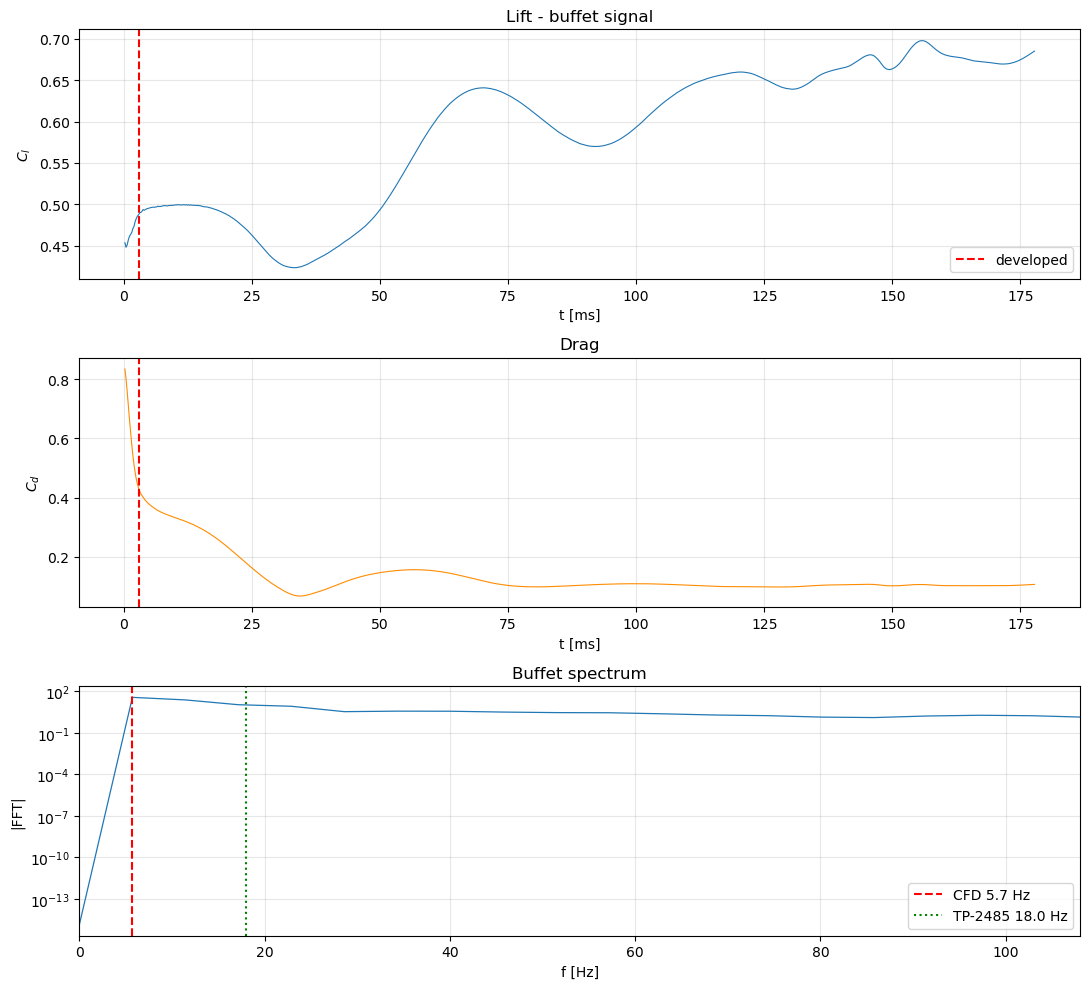

Saved: buffet_history.png


In [14]:
# CELL 12 Cl/Cd history + onset + FFT

import numpy as np, matplotlib.pyplot as plt

cl = np.loadtxt("cl_history.out", skiprows=3)
cd = np.loadtxt("cd_history.out", skiprows=3)
steps, cl_vals, cd_vals = cl[:,0], cl[:,1], cd[:,1]
t = steps * DT

win = STEPS_PER_CYCLE // 2            # envelope window ~ half a cycle
env = np.array([cl_vals[max(0,i-win):i+1].ptp() for i in range(len(cl_vals))])
final_amp = env[-win:].mean()
dev = env > 0.90*final_amp
step_dev = int(steps[np.argmax(dev)]) if dev.any() else int(0.3*len(steps))
t_developed = step_dev * DT
print(f"Buffet developed at step {step_dev} (t={t_developed*1e3:.1f} ms = "
      f"{t_developed/T_BUFFET:.1f} cycles); Cl amp p-p = {final_amp:.4f}")

sig = cl_vals[step_dev:] - cl_vals[step_dev:].mean()
freqs = np.fft.rfftfreq(len(sig), d=DT); amp = np.abs(np.fft.rfft(sig))
ip = 1 + int(np.argmax(amp[1:])); f_peak = freqs[ip]
St_cfd = f_peak*CHORD/U_INF; fbar_cfd = 2*np.pi*f_peak*CHORD/U_INF
print(f"\nBuffet frequency (FFT of Cl):")
print(f"   f    = {f_peak:.2f} Hz   (ref {F_BUFFET:.2f} Hz)")
print(f"   St   = {St_cfd:.4f}      (ref {ST_REF:.4f})")
print(f"   fbar = {fbar_cfd:.4f}    (TP-2485 {FBAR:.3f})")

fig, ax = plt.subplots(3,1, figsize=(11,10))
ax[0].plot(t*1e3, cl_vals, lw=0.8); ax[0].axvline(t_developed*1e3, color="r", ls="--", label="developed")
ax[0].set_xlabel("t [ms]"); ax[0].set_ylabel("$C_l$"); ax[0].set_title("Lift - buffet signal"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(t*1e3, cd_vals, lw=0.8, color="darkorange"); ax[1].axvline(t_developed*1e3, color="r", ls="--")
ax[1].set_xlabel("t [ms]"); ax[1].set_ylabel("$C_d$"); ax[1].set_title("Drag"); ax[1].grid(alpha=0.3)
ax[2].semilogy(freqs, amp, lw=0.9); ax[2].axvline(f_peak, color="r", ls="--", label=f"CFD {f_peak:.1f} Hz")
ax[2].axvline(F_BUFFET, color="g", ls=":", label=f"TP-2485 {F_BUFFET:.1f} Hz")
ax[2].set_xlim(0, 6*F_BUFFET); ax[2].set_xlabel("f [Hz]"); ax[2].set_ylabel("|FFT|"); ax[2].set_title("Buffet spectrum"); ax[2].legend(); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("buffet_history.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved: buffet_history.png")

## Section A Export snapshots for POD/DMD

Exports x, y, **cell volume** (for volume-weighted POD), U, V, pressure, and Mach.
Volume weighting matters on this mesh: 50 stacked BL layers means thousands of tiny
near-wall cells that would otherwise dominate the SVD energy.

In [ ]:
# CELL A Export snapshots to CSV

import os, glob, numpy as np

snap_files = sorted(glob.glob("snap*.dat.h5"))
print(f"Found {len(snap_files)} snapshots")
if not snap_files:
    raise FileNotFoundError("No snap*.dat.h5 - did the run complete?")

surfaces = session.settings.results.surfaces
SURFACE = None
for kw in ("interior","fluid","surface_body"):
    for s in surfaces.zone_surface():
        if kw in s.lower(): SURFACE = s; break
    if SURFACE: break
if SURFACE is None:
    raise RuntimeError("No interior surface - set SURFACE manually")
print(f"Sampling surface: '{SURFACE}'")

fd = session.fields.field_data
def get_field(name):
    r = fd.get_scalar_field_data(field_name=name, surfaces=[SURFACE])
    for k,v in r.items():
        if hasattr(v,"data"): return np.asarray(v.data).flatten()
        if isinstance(v,dict):
            for _,vv in v.items(): return np.asarray(vv).flatten()
        return np.asarray(v).flatten()
    raise RuntimeError(f"Could not extract '{name}'")

session.settings.file.read_data(file_name=snap_files[0])
x = get_field("x-coordinate"); y = get_field("y-coordinate")
# >>> KEY: cell volume for volume-weighted POD.
try:
    vol = get_field("cell-volume"); print("Got cell-volume (volume-weighted POD).")
except Exception as e:
    print(f"cell-volume unavailable ({e}); uniform weights."); vol = np.ones_like(x)

n = len(x)
print(f"Mesh: {n} points; x/c [{x.min()/CHORD:.2f},{x.max()/CHORD:.2f}] "
      f"y/c [{y.min()/CHORD:.2f},{y.max()/CHORD:.2f}]")
np.savetxt("buffet_xy.csv", np.column_stack([x,y,vol]), delimiter=",", header="x,y,vol", comments="")

U=np.zeros((n,len(snap_files))); V=np.zeros_like(U); P=np.zeros_like(U); Mn=np.zeros_like(U)
print(f"Extracting U,V,p,Mach from {len(snap_files)} snapshots ...")
for i,f in enumerate(snap_files):
    session.settings.file.read_data(file_name=f)
    U[:,i]=get_field("x-velocity"); V[:,i]=get_field("y-velocity"); P[:,i]=get_field("pressure")
    try: Mn[:,i]=get_field("mach-number")
    except Exception: pass
    if (i+1)%10==0 or i==len(snap_files)-1: print(f"   {i+1}/{len(snap_files)}", end="\r")
print()
np.savetxt("buffet_U.csv", U, delimiter=","); np.savetxt("buffet_V.csv", V, delimiter=",")
np.savetxt("buffet_P.csv", P, delimiter=","); np.savetxt("buffet_M.csv", Mn, delimiter=",")
snap_steps = np.array([int(os.path.basename(f).split("-")[-1].split(".")[0]) for f in snap_files])
np.savetxt("buffet_times.csv", np.column_stack([snap_steps, snap_steps*DT]),
           delimiter=",", header="step,time_s", comments="")
print(f"Exported buffet_xy/U/V/P/M/times.csv  ({T_BUFFET/(snap_steps[1]*DT-snap_steps[0]*DT):.1f} snaps/cycle)")

## Section B Load data  *(no Fluent needed from here)*

In [16]:
# CELL B Load snapshots (Fluent-free)

import numpy as np, matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

xyv   = np.loadtxt("buffet_xy.csv", delimiter=",", skiprows=1)
U_full= np.loadtxt("buffet_U.csv", delimiter=","); V_full=np.loadtxt("buffet_V.csv", delimiter=",")
P_full= np.loadtxt("buffet_P.csv", delimiter=","); M_full=np.loadtxt("buffet_M.csv", delimiter=",")
times_all = np.loadtxt("buffet_times.csv", delimiter=",", skiprows=1)
xa, ya, vol = xyv[:,0], xyv[:,1], xyv[:,2]

# standalone constants (this mesh: chord = 1 m)
CHORD=1.0; U_INF=257.09; ST_REF=0.0700
# T_buffet for c=1 m: recompute from St
import math
T_BUFFET = 1.0/(ST_REF*U_INF/CHORD)

snap_times = times_all[:,1]
if "t_developed" in dir():
    keep = snap_times >= t_developed; src = f"t>{t_developed*1e3:.1f} ms"
    if keep.sum()<20:
        keep = snap_times >= snap_times[int(0.30*len(snap_times))]; src="fallback 30%"
else:
    keep = np.zeros(len(snap_times),bool); keep[int(0.30*len(snap_times)):]=True; src="fallback 30%"

U=U_full[:,keep]; V=V_full[:,keep]; P=P_full[:,keep]; Mn=M_full[:,keep]
times=times_all[keep]; dt_snap=times[1,1]-times[0,1]
n_points,n_snaps = U.shape
print(f"Window: {src}; {n_snaps} snapshots; {T_BUFFET/dt_snap:.1f} snaps/cycle; "
      f"{(times[-1,1]-times[0,1])/T_BUFFET:.1f} cycles")

d = np.diff(times[:,0])
print("Step numbers monotonic - no run-seam contamination." if np.all(d>0)
      else "WARNING: non-monotonic steps - two runs concatenated?")

xc, yc = xa/CHORD, ya/CHORD
mask_near = (xc>-0.5)&(xc<2.5)&(np.abs(yc)<1.0)
triang = Triangulation(xc[mask_near], yc[mask_near])
print(f"Plot region: {mask_near.sum()} points. Data loaded.")

Window: t>2.9 ms; 207 snapshots; 20.8 snaps/cycle; 9.9 cycles
Step numbers monotonic - no run-seam contamination.
Plot region: 8072 points. Data loaded.


### Mean/variance - where is the buffet?

var(u) should light up on the **upper surface, x/c ≈ 0.3–0.6** (oscillating shock)
plus the separated wake. If it's spread over the wake with nothing on the surface,
it's stall/shedding, not buffet check α and M.

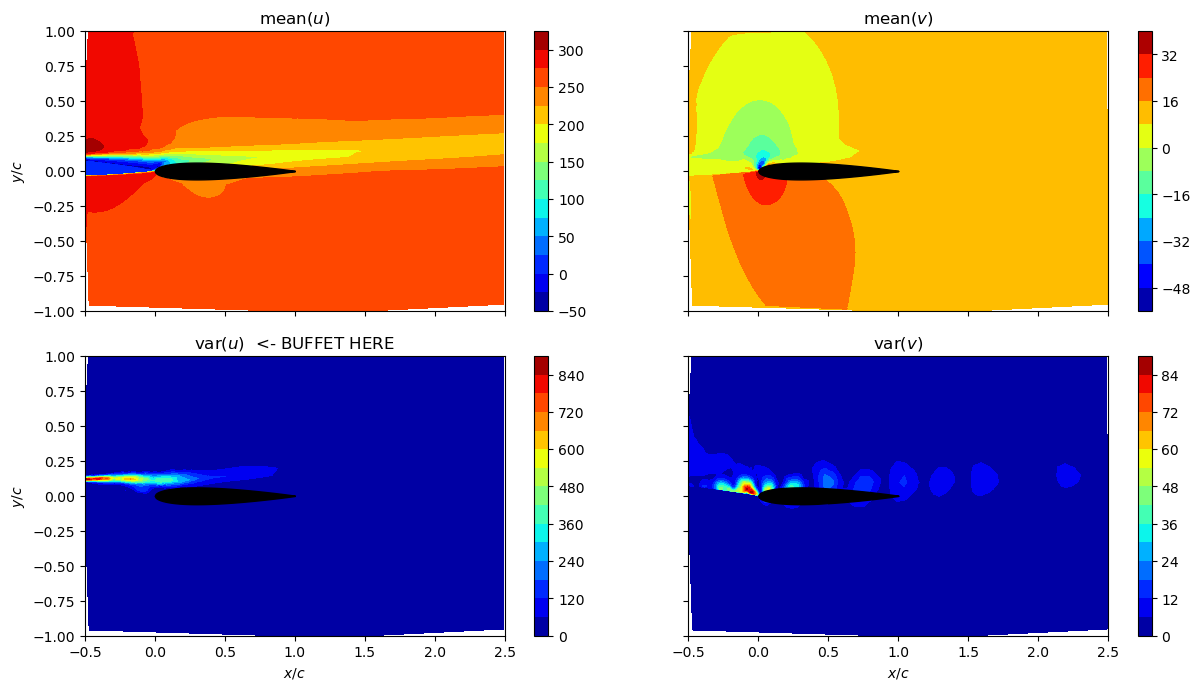

Saved. var(u) band on upper surface x/c~0.3-0.6 = buffet; only in wake = stall/shedding.


In [17]:
# CELL B2 Mean/variance (buffet localisation)

def add_airfoil(ax):
    xx=np.linspace(0,1,200); t=0.12
    yt=5*t*(0.2969*np.sqrt(xx)-0.1260*xx-0.3516*xx**2+0.2843*xx**3-0.1015*xx**4)
    ax.fill_between(xx,0,yt,color="k",zorder=5); ax.fill_between(xx,-yt,0,color="k",zorder=5)

fig,ax = plt.subplots(2,2, figsize=(13,7), sharex=True, sharey=True)
for a,(f,ttl) in zip(ax.flatten(), [
        (U[mask_near].mean(1), r"mean($u$)"), (V[mask_near].mean(1), r"mean($v$)"),
        (U[mask_near].var(1),  r"var($u$)  <- BUFFET HERE"), (V[mask_near].var(1), r"var($v$)")]):
    tcf=a.tricontourf(triang,f,levels=14,cmap="jet"); plt.colorbar(tcf,ax=a)
    add_airfoil(a); a.set_aspect("equal","box"); a.set_xlim(-0.5,2.5); a.set_ylim(-1,1); a.set_title(ttl)
ax[1,0].set_xlabel("$x/c$"); ax[1,1].set_xlabel("$x/c$"); ax[0,0].set_ylabel("$y/c$"); ax[1,0].set_ylabel("$y/c$")
plt.tight_layout(); plt.savefig("buffet_mean_var.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved. var(u) band on upper surface x/c~0.3-0.6 = buffet; only in wake = stall/shedding.")

# Section C Volume-weighted POD

Snapshot matrix with **√V row weighting** (physically-correct volume-integrated
energy) and **stacked [u; v]** (so an oscillation is a proper mode pair), mean
removed. Leading pair = the shock-oscillation ("breathing") mode.

Snapshot matrix (228868, 207); volume ratio max/min = 7.7e+05
POD energy:
   mode 1: 36.85%  (cum 36.85%)
   mode 2: 18.75%  (cum 55.60%)
   mode 3: 11.26%  (cum 66.86%)
   mode 4:  8.22%  (cum 75.08%)
   mode 5:  3.67%  (cum 78.75%)
   mode 6:  2.72%  (cum 81.48%)
   mode 7:  2.03%  (cum 83.51%)
   mode 8:  1.48%  (cum 84.99%)
   99% energy at 26 modes; expect a dominant PAIR (shock oscillation).


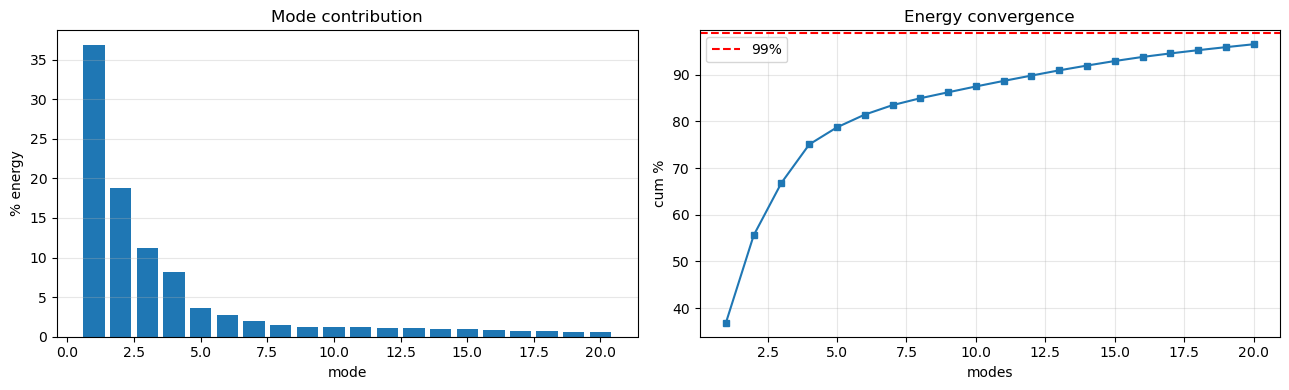

Saved: buffet_pod_spectrum.png


In [18]:
# CELL C Volume-weighted POD

# >>> KEY: sqrt(cell volume) weights -> SVD minimises volume-integrated energy.
weights = np.sqrt(vol)[:,None]
# >>> KEY: stack [u;v] so an oscillation appears as a mode PAIR.
dm = np.zeros((2*n_points, n_snaps))
dm[:n_points,:] = U*weights; dm[n_points:,:] = V*weights
# >>> KEY: remove temporal mean -> POD reveals fluctuations, not the mean flow.
dm -= dm.mean(axis=1, keepdims=True)
print(f"Snapshot matrix {dm.shape}; volume ratio max/min = {vol.max()/vol.min():.1e}")

Phi, S, PsiT = np.linalg.svd(dm, full_matrices=False)
ef = S**2/(S**2).sum(); ec = np.cumsum(ef)
print("POD energy:")
for i in range(min(8,len(S))): print(f"   mode {i+1}: {ef[i]*100:5.2f}%  (cum {ec[i]*100:5.2f}%)")
print(f"   99% energy at {int(np.argmax(ec>=0.99))+1} modes; expect a dominant PAIR (shock oscillation).")

fig,ax=plt.subplots(1,2,figsize=(13,4)); n=min(20,len(S))
ax[0].bar(range(1,n+1), ef[:n]*100); ax[0].set_xlabel("mode"); ax[0].set_ylabel("% energy"); ax[0].set_title("Mode contribution"); ax[0].grid(alpha=0.3,axis="y")
ax[1].plot(range(1,n+1), ec[:n]*100, "s-", ms=4); ax[1].axhline(99,color="r",ls="--",label="99%"); ax[1].set_xlabel("modes"); ax[1].set_ylabel("cum %"); ax[1].set_title("Energy convergence"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("buffet_pod_spectrum.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved: buffet_pod_spectrum.png")

### POD mode shapes

Un-weight (÷√V) before plotting. Modes 1–2 should hug the upper surface at
x/c ≈ 0.3–0.6 with a dipole straddling the mean shock, the buffet mode.

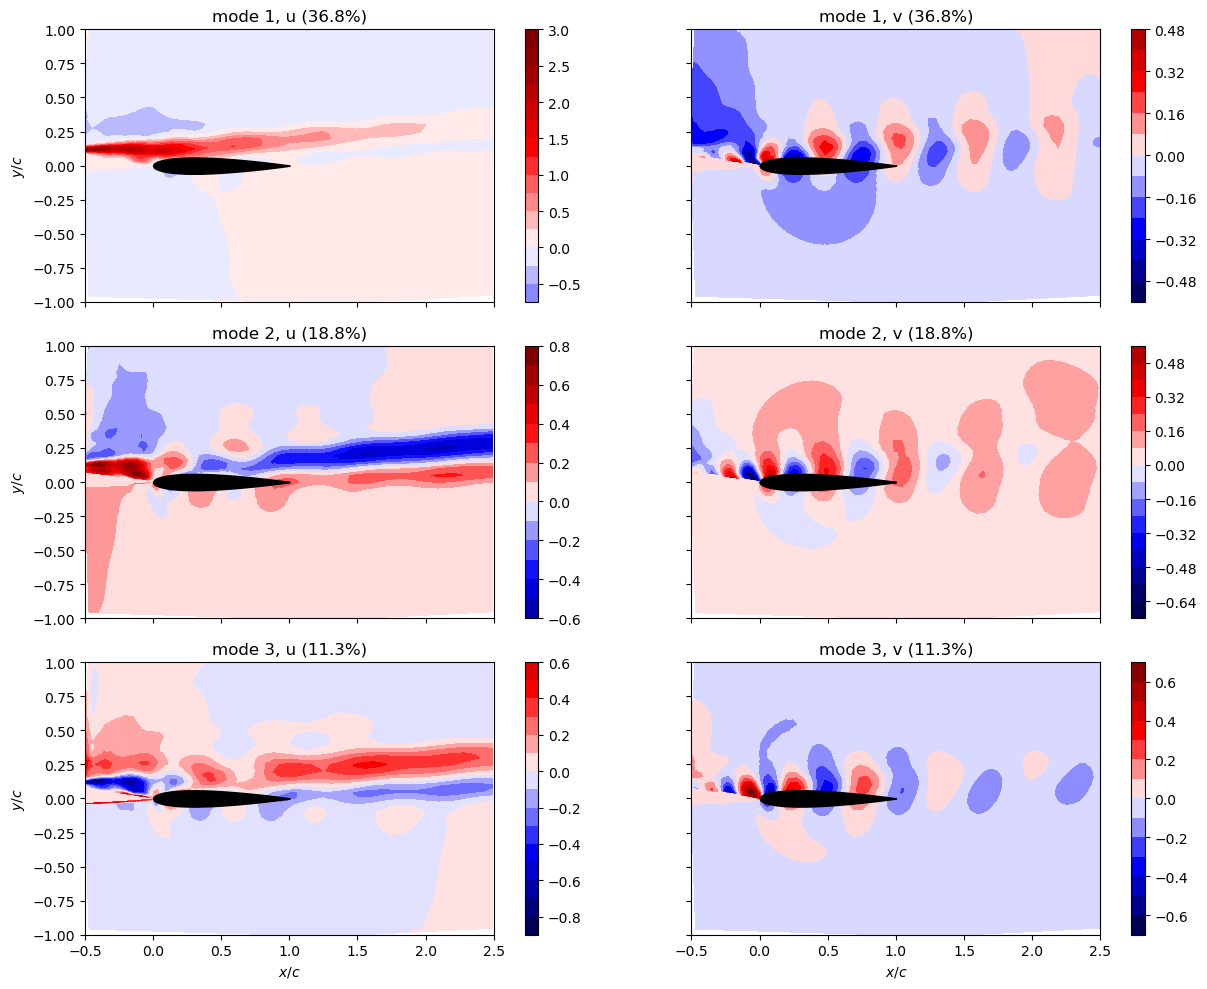

Saved: buffet_pod_modes.png


In [19]:
# CELL C2 POD mode shapes

fig,ax=plt.subplots(3,2,figsize=(13,10),sharex=True,sharey=True)
for i in range(3):
    # >>> KEY: divide by weights to un-weight back to physical space.
    mu=Phi[:n_points,i]/weights[:,0]; mv=Phi[n_points:,i]/weights[:,0]
    for j,(m,comp) in enumerate([(mu,"u"),(mv,"v")]):
        a=ax[i,j]; lim=np.abs(m[mask_near]).max()
        tcf=a.tricontourf(triang,m[mask_near],levels=14,cmap="seismic",vmin=-lim,vmax=lim)
        plt.colorbar(tcf,ax=a); add_airfoil(a); a.set_aspect("equal","box")
        a.set_xlim(-0.5,2.5); a.set_ylim(-1,1); a.set_title(f"mode {i+1}, {comp} ({ef[i]*100:.1f}%)")
for a in ax[-1,:]: a.set_xlabel("$x/c$")
for a in ax[:,0]: a.set_ylabel("$y/c$")
plt.tight_layout(); plt.savefig("buffet_pod_modes.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved: buffet_pod_modes.png")

### Temporal coefficients + phase portrait

a₁, a₂ should be clean sinusoids ~90° apart; a₂-vs-a₁ a closed circle = saturated
limit cycle. An inward spiral means you didn't discard enough transient.

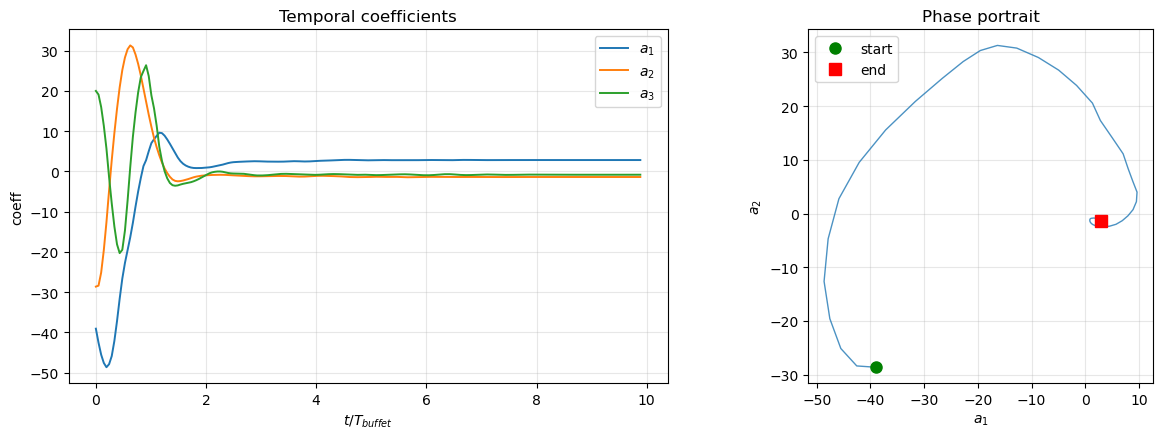

Saved. Closed circle = saturated buffet limit cycle.


In [21]:
# CELL C3 Temporal coefficients + phase portrait

A = np.diag(S) @ PsiT
t_rel = times[:,1]-times[0,1]
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
for i in range(3): ax[0].plot(t_rel/T_BUFFET, A[i], lw=1.4, label=f"$a_{{{i+1}}}$")
ax[0].set_xlabel("$t/T_{buffet}$"); ax[0].set_ylabel("coeff"); ax[0].set_title("Temporal coefficients"); ax[0].legend(); ax[0].grid(alpha=0.3)
# >>> KEY DIAGNOSTIC: closed orbit = limit cycle; spiral = residual transient.
ax[1].plot(A[0],A[1],lw=1.0,alpha=0.8); ax[1].plot(A[0,0],A[1,0],"go",ms=8,label="start"); ax[1].plot(A[0,-1],A[1,-1],"rs",ms=8,label="end")
ax[1].set_xlabel("$a_1$"); ax[1].set_ylabel("$a_2$"); ax[1].set_title("Phase portrait"); ax[1].set_aspect("equal","box"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("buffet_pod_coeffs.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved. Closed circle = saturated buffet limit cycle.")

# Section D DMD

POD ranks by energy; DMD ranks by **dynamics** (each mode = one frequency + a
growth rate). Select the buffet mode by: (a) St in the physical band **and**
(b) |λ| ≈ 1 (neutral -> self-sustaining).

In [22]:
# CELL D DMD

X, Xp = dm[:,:-1], dm[:,1:]
Ux,Sx,VxT = np.linalg.svd(X, full_matrices=False)
# >>> KEY: rank truncation - keep sv>0.1% of max, capped 20 (beats energy rule).
r = max(4, min(int(np.sum(Sx/Sx[0]>1e-3)), 20))
print(f"DMD rank r = {r}")
Ur,Sr,Vr = Ux[:,:r], np.diag(Sx[:r]), VxT[:r,:].conj().T
At = Ur.conj().T @ Xp @ Vr @ np.linalg.inv(Sr)
ev,W = np.linalg.eig(At)
Phid = Xp @ Vr @ np.linalg.inv(Sr) @ W
omega = np.log(ev)/dt_snap
freqs = omega.imag/(2*np.pi); growth = omega.real; mags = np.abs(ev)
b = np.linalg.lstsq(Phid, X[:,0], rcond=None)[0]; amps=np.abs(b)
St_all = freqs*CHORD/U_INF; fbar_all = 2*np.pi*freqs*CHORD/U_INF

order = np.argsort(-amps)
print(f"\n  {'mode':>4}{'f[Hz]':>10}{'St':>9}{'fbar':>8}{'|lam|':>7}{'growth':>11}{'|amp|':>10}")
for i in order[:min(12,r)]:
    print(f"  {i:>4}{freqs[i]:>+10.2f}{St_all[i]:>+9.4f}{fbar_all[i]:>+8.3f}"
          f"{mags[i]:>7.4f}{growth[i]:>+11.2f}{amps[i]:>10.3e}")

# >>> KEY SELECTION: St in band AND |lam|~1 (neutral). Not by amplitude.
lo,hi = 0.5*ST_REF, 2.0*ST_REF
cand = np.where((np.abs(St_all)>lo)&(np.abs(St_all)<hi))[0]
if len(cand):
    score = amps[cand]/(1.0+50.0*np.abs(growth[cand])*dt_snap)
    dom = cand[int(np.argmax(score))]
    St_dom, fbar_dom = abs(St_all[dom]), abs(fbar_all[dom])
    print(f"\nBUFFET mode #{dom}: f={abs(freqs[dom]):.2f} Hz, St={St_dom:.4f} (ref {ST_REF:.4f}), "
          f"fbar={fbar_dom:.4f} (TP-2485 {FBAR:.3f}), |lam|={mags[dom]:.4f}, growth={growth[dom]:+.2f}")
else:
    dom, St_dom, fbar_dom = None, float("nan"), float("nan")
    print(f"\nNo mode in band St({lo:.3f},{hi:.3f}) - check AoA/M or SNAP_FREQ aliasing.")

DMD rank r = 20

  mode     f[Hz]       St    fbar  |lam|     growth     |amp|
    14    -33.21  -0.1292  -0.812 0.7642    -100.89 1.653e+02
    13    +33.21  +0.1292  +0.812 0.7642    -100.89 1.653e+02
    19    -23.10  -0.0898  -0.564 0.8800     -47.95 9.314e+01
    18    +23.10  +0.0898  +0.564 0.8800     -47.95 9.314e+01
    17    -11.24  -0.0437  -0.275 0.9127     -34.28 7.843e+01
    16    +11.24  +0.0437  +0.275 0.9127     -34.28 7.843e+01
    12    -47.09  -0.1832  -1.151 0.8180     -75.33 7.415e+01
    11    +47.09  +0.1832  +1.151 0.8180     -75.33 7.415e+01
    15     +0.00  +0.0000  +0.000 0.9189     -31.73 6.053e+01
     9    +67.39  +0.2621  +1.647 0.7929     -87.03 4.324e+01
    10    -67.39  -0.2621  -1.647 0.7929     -87.03 4.324e+01
     1   +153.54  +0.5972  +3.752 0.8746     -50.24 1.191e+01

BUFFET mode #17: f=11.24 Hz, St=0.0437 (ref 0.0700), fbar=0.2748 (TP-2485 0.440), |lam|=0.9127, growth=-34.28


### Eigenvalue spectrum unit-circle test

On the circle (|λ|=1) = self-sustaining = buffet. Inside = decaying, outside =
growing. The buffet mode must sit essentially on the circle.

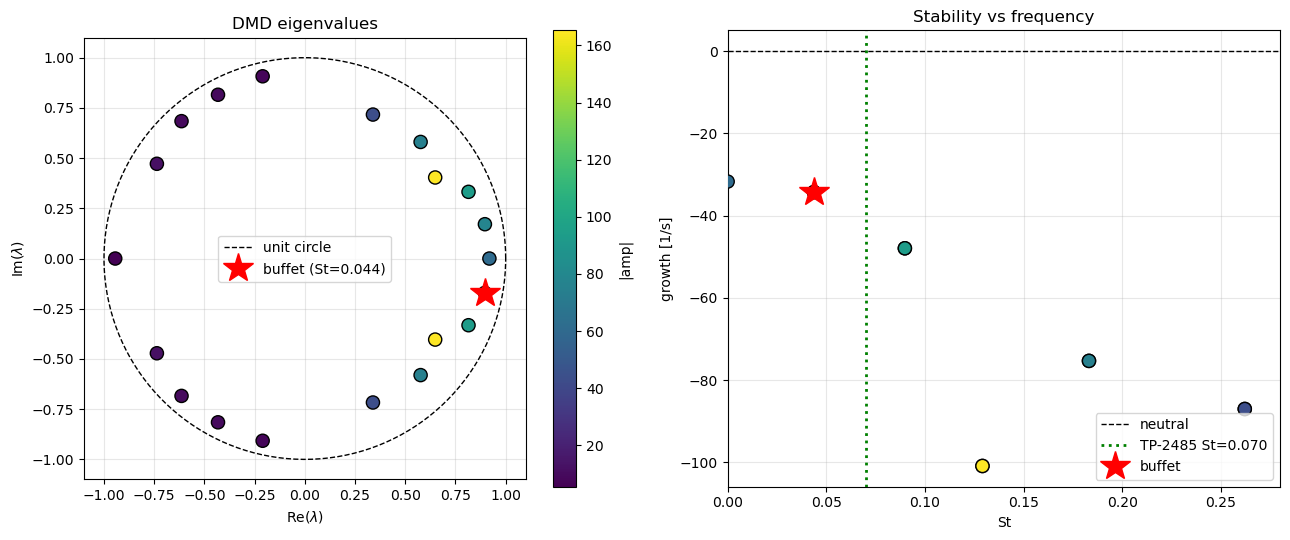

Saved. Buffet mode should sit ON the circle (growth~0) AND at St~0.070.


In [23]:
# CELL D2 — Eigenvalue spectrum

fig,ax=plt.subplots(1,2,figsize=(13,5.5))
th=np.linspace(0,2*np.pi,300); ax[0].plot(np.cos(th),np.sin(th),"k--",lw=1,label="unit circle")
sc=ax[0].scatter(ev.real,ev.imag,c=amps,s=90,cmap="viridis",edgecolors="k",zorder=5); plt.colorbar(sc,ax=ax[0],label="|amp|")
if dom is not None: ax[0].plot(ev[dom].real,ev[dom].imag,"r*",ms=22,zorder=6,label=f"buffet (St={St_dom:.3f})")
ax[0].set_xlabel("Re$(\\lambda)$"); ax[0].set_ylabel("Im$(\\lambda)$"); ax[0].set_title("DMD eigenvalues"); ax[0].set_aspect("equal","box"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].axhline(0,color="k",lw=1,ls="--",label="neutral"); ax[1].axvline(ST_REF,color="g",ls=":",lw=2,label=f"TP-2485 St={ST_REF:.3f}")
ax[1].scatter(np.abs(St_all),growth,c=amps,s=90,cmap="viridis",edgecolors="k",zorder=5)
if dom is not None: ax[1].plot(St_dom,growth[dom],"r*",ms=22,zorder=6,label="buffet")
ax[1].set_xlabel("St"); ax[1].set_ylabel("growth [1/s]"); ax[1].set_xlim(0,4*ST_REF); ax[1].set_title("Stability vs frequency"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("buffet_dmd_eigs.png", dpi=140, bbox_inches="tight"); plt.show()
print(f"Saved. Buffet mode should sit ON the circle (growth~0) AND at St~{ST_REF:.3f}.")

### The buffet DMD mode

Real/imag parts are the shock at two phases 90° apart the fore-aft shock sweep.

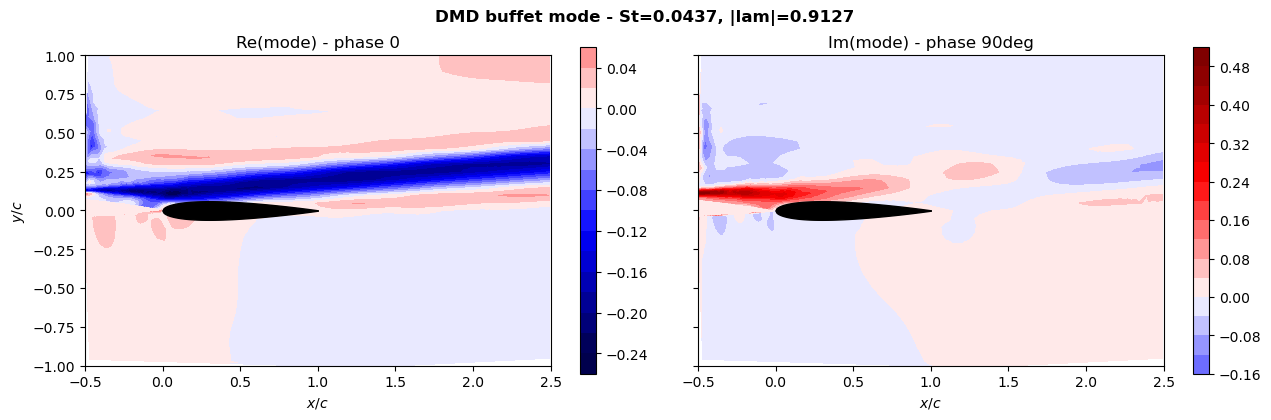

Saved: buffet_dmd_mode.png


In [24]:
# CELL D3 Buffet mode shape

if dom is not None:
    m = Phid[:,dom]; mr = m[:n_points].real/weights[:,0]; mi = m[:n_points].imag/weights[:,0]
    fig,ax=plt.subplots(1,2,figsize=(13,4),sharex=True,sharey=True)
    for a,f,ttl in [(ax[0],mr,"Re(mode) - phase 0"),(ax[1],mi,"Im(mode) - phase 90deg")]:
        lim=np.abs(f[mask_near]).max(); tcf=a.tricontourf(triang,f[mask_near],levels=16,cmap="seismic",vmin=-lim,vmax=lim)
        plt.colorbar(tcf,ax=a); add_airfoil(a); a.set_aspect("equal","box"); a.set_xlim(-0.5,2.5); a.set_ylim(-1,1); a.set_xlabel("$x/c$"); a.set_title(ttl)
    ax[0].set_ylabel("$y/c$")
    plt.suptitle(f"DMD buffet mode - St={St_dom:.4f}, |lam|={mags[dom]:.4f}", fontweight="bold")
    plt.tight_layout(); plt.savefig("buffet_dmd_mode.png", dpi=140, bbox_inches="tight"); plt.show()
    print("Saved: buffet_dmd_mode.png")
else:
    print("No buffet mode - skipping.")

### Reconstruction + out-of-sample prediction

Reconstruction (fitted window) is a weak check. The real test is a **70/30 split**:
fit DMD on the first 70%, predict the unseen last 30%.

Reconstruction error (fitted): mean 94.11%  max 119.72%
Out-of-sample: fit 144, predict 63
OUT-OF-SAMPLE error: mean 100.00%  max 100.00%


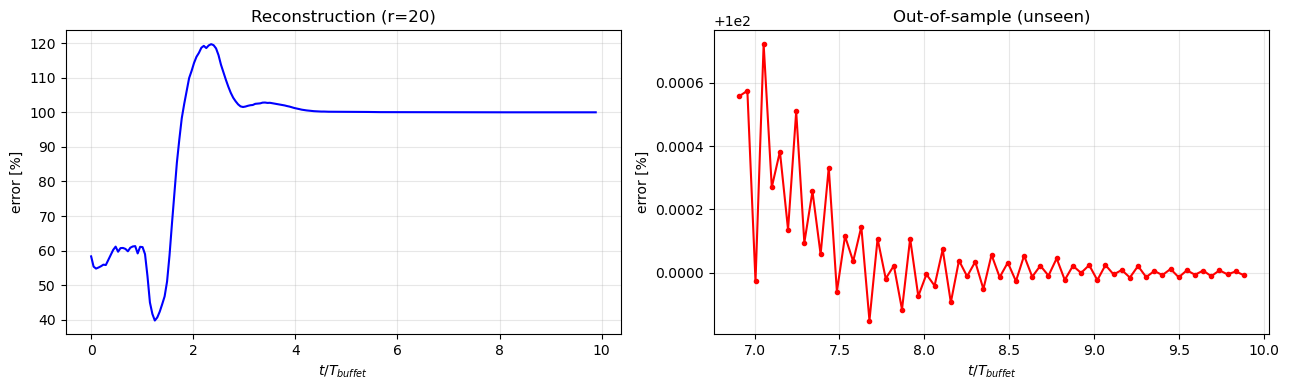

Saved. Low out-of-sample error = the surrogate PREDICTS buffet - the deliverable.


In [25]:
# CELL D4 Reconstruction + out-of-sample prediction

t_dev = times[:,1]-times[0,1]
td = np.zeros((r, dm.shape[1]), dtype=complex)
for k in range(dm.shape[1]): td[:,k] = b*np.exp(omega*t_dev[k])
Qr = (Phid @ td).real
err = np.linalg.norm(Qr-dm,axis=0)/(np.linalg.norm(dm,axis=0)+1e-12)
print(f"Reconstruction error (fitted): mean {err.mean()*100:.2f}%  max {err.max()*100:.2f}%")

n_fit = int(0.70*n_snaps)
print(f"Out-of-sample: fit {n_fit}, predict {n_snaps-n_fit}")
Xf,Xfp = dm[:,:n_fit-1], dm[:,1:n_fit]
Uf,Sf,VfT = np.linalg.svd(Xf, full_matrices=False)
rf = max(4, min(int(np.sum(Sf/Sf[0]>1e-3)),20))
Urf,Srf,Vrf = Uf[:,:rf], np.diag(Sf[:rf]), VfT[:rf,:].conj().T
Atf = Urf.conj().T @ Xfp @ Vrf @ np.linalg.inv(Srf)
evf,Wf = np.linalg.eig(Atf); Phif = Xfp @ Vrf @ np.linalg.inv(Srf) @ Wf
omf = np.log(evf)/dt_snap; bf = np.linalg.lstsq(Phif, Xf[:,0], rcond=None)[0]
perr = np.array([np.linalg.norm((Phif@(bf*np.exp(omf*t_dev[k]))).real-dm[:,k])/(np.linalg.norm(dm[:,k])+1e-12)
                 for k in range(n_fit,n_snaps)])
print(f"OUT-OF-SAMPLE error: mean {perr.mean()*100:.2f}%  max {perr.max()*100:.2f}%")

fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(t_dev/T_BUFFET, err*100, "b-"); ax[0].set_xlabel("$t/T_{buffet}$"); ax[0].set_ylabel("error [%]"); ax[0].set_title(f"Reconstruction (r={r})"); ax[0].grid(alpha=0.3)
ax[1].plot(t_dev[n_fit:]/T_BUFFET, perr*100, "r-o", ms=3); ax[1].set_xlabel("$t/T_{buffet}$"); ax[1].set_ylabel("error [%]"); ax[1].set_title("Out-of-sample (unseen)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("buffet_dmd_error.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved. Low out-of-sample error = the surrogate PREDICTS buffet - the deliverable.")

# Section E Validation against NASA TP-2485

Reference: McDevitt & Okuno, TP-2485(1985), **Table 4 row 3** (M=0.77, α=4°, Re=10⁷) and Figure 17 (Cp).

| Quantity | TP-2485 | Source |
|---|---|---|
| Reduced frequency | f̄ = 0.44 -> St = 0.070 | Table 4 |
| Convention | f̄ = 2πfc/U | Nomenclature p.iii |
| Conditions | M=0.77, α=4°, Re=10⁷ | Table 4 |

  VALIDATION vs NASA TP-2485 (1985) - Table 4 row 3
  NACA 0012, M=0.77, alpha=4 deg, Re=1e7

  Quantity                         Ours             Reference   Verdict
  ----------------------------------------------------------------------
  Strouhal (Cl FFT)              0.0222           0.060-0.080     CHECK
  Strouhal (DMD)                 0.0437           0.060-0.080     CHECK
  Reduced freq fbar              0.1398        0.44 (Table 4)     CHECK
  AoA (this run)                   4.00               4.0 deg      PASS
  ----------------------------------------------------------------------

  Cross-check FFT vs DMD: 96.6% apart -> INCONSISTENT (aliasing/transient?)

  Modelling limitations to DOCUMENT (not bugs):
   - 2D URANS: over-predicts Cl-oscillation amplitude vs 3D experiment.
   - Small domain (6c/15c) + free-air: some far-field shift of shock position.
   - Fully turbulent from LE (no transition model).


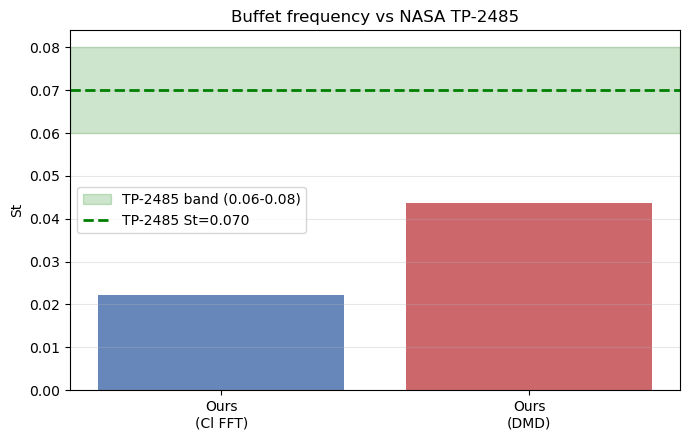

Saved: buffet_validation.png


In [26]:
# CELL E Validation vs TP-2485

print("="*74)
print("  VALIDATION vs NASA TP-2485 (1985) - Table 4 row 3")
print("  NACA 0012, M=0.77, alpha=4 deg, Re=1e7")
print("="*74)

FBAR_REF = 0.44; ST_LO, ST_HI = 0.060, 0.080
St_fft = St_cfd if "St_cfd" in dir() else float("nan")
St_dmd = St_dom if "St_dom" in dir() else float("nan")
def verdict(v,lo,hi): return "N/A" if np.isnan(v) else ("PASS" if lo<=v<=hi else "CHECK")

print(f"\n  {'Quantity':<26}{'Ours':>11}{'Reference':>22}{'Verdict':>10}")
print("  "+"-"*70)
print(f"  {'Strouhal (Cl FFT)':<26}{St_fft:>11.4f}{'0.060-0.080':>22}{verdict(St_fft,ST_LO,ST_HI):>10}")
print(f"  {'Strouhal (DMD)':<26}{St_dmd:>11.4f}{'0.060-0.080':>22}{verdict(St_dmd,ST_LO,ST_HI):>10}")
if not np.isnan(St_fft):
    fb=2*np.pi*St_fft
    print(f"  {'Reduced freq fbar':<26}{fb:>11.4f}{'0.44 (Table 4)':>22}{verdict(fb,0.38,0.50):>10}")
print(f"  {'AoA (this run)':<26}{AOA:>11.2f}{'4.0 deg':>22}{verdict(AOA,3.5,4.5):>10}")
print("  "+"-"*70)

if not (np.isnan(St_fft) or np.isnan(St_dmd)):
    rel=abs(St_fft-St_dmd)/max(St_fft,1e-9)*100
    print(f"\n  Cross-check FFT vs DMD: {rel:.1f}% apart -> "
          f"{'consistent (real buffet mode)' if rel<10 else 'INCONSISTENT (aliasing/transient?)'}")

print("\n  Modelling limitations to DOCUMENT (not bugs):")
print("   - 2D URANS: over-predicts Cl-oscillation amplitude vs 3D experiment.")
print("   - Small domain (6c/15c) + free-air: some far-field shift of shock position.")
print("   - Fully turbulent from LE (no transition model).")
print("="*74)

fig,ax=plt.subplots(figsize=(7,4.5))
ax.bar(["Ours\n(Cl FFT)","Ours\n(DMD)"], [St_fft,St_dmd], color=["#4C72B0","#C44E52"], alpha=0.85)
ax.axhspan(ST_LO,ST_HI,color="green",alpha=0.20,label=f"TP-2485 band ({ST_LO}-{ST_HI})")
ax.axhline(ST_REF,color="green",ls="--",lw=2,label=f"TP-2485 St={ST_REF:.3f}")
ax.set_ylabel("St"); ax.set_title("Buffet frequency vs NASA TP-2485"); ax.legend(); ax.grid(alpha=0.3,axis="y")
plt.tight_layout(); plt.savefig("buffet_validation.png", dpi=140, bbox_inches="tight"); plt.show()
print("Saved: buffet_validation.png")